In [1]:
# ===============================
# Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ===============================
# Load Dataset
# ===============================
df = pd.read_csv('/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore.csv')

print("Shape:", df.shape)
print(df.head())

Shape: (10841, 13)
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018               1.0.0   
1  Ar

In [3]:
# ===============================
# 4.1 Problem Definition
# ===============================

print("----- Problem Definition -----\n")

print("Dataset Selected:")
print("This project uses the Google Play Store Apps dataset collected from Kaggle.\n")

print("Real-World Topic:")
print("The dataset represents mobile application data from the Google Play Store, including app ratings, installs, pricing, and categories. ")
print("It reflects user behavior, app popularity, and market trends in the mobile app industry.\n")

print("Analytical Questions:")
print("1. Do free apps receive more installs compared to paid apps?")
print("2. Is there a relationship between app ratings and number of installs?")
print("3. Which app categories are the most popular based on installs and ratings?\n")

print("Why These Questions Matter:")
print("Understanding these questions helps developers and businesses make better decisions regarding app pricing, quality improvement, and category selection.")
print("It also provides insights into user preferences and market demand in the app ecosystem.\n")

----- Problem Definition -----

Dataset Selected:
This project uses the Google Play Store Apps dataset collected from Kaggle.

Real-World Topic:
The dataset represents mobile application data from the Google Play Store, including app ratings, installs, pricing, and categories. 
It reflects user behavior, app popularity, and market trends in the mobile app industry.

Analytical Questions:
1. Do free apps receive more installs compared to paid apps?
2. Is there a relationship between app ratings and number of installs?
3. Which app categories are the most popular based on installs and ratings?

Why These Questions Matter:
Understanding these questions helps developers and businesses make better decisions regarding app pricing, quality improvement, and category selection.
It also provides insights into user preferences and market demand in the app ecosystem.



In [4]:
# ===============================
# 4.2 Data Understanding
# ===============================

print("----- Data Understanding -----\n")

# Dataset Shape
print("Dataset Shape (Rows, Columns):")
print(df.shape)
print("\nExplanation: The dataset contains", df.shape[0], "rows and", df.shape[1], 
      "columns, which means it has sufficient data for meaningful analysis.\n")

# Column Names
print("Column Names:")
print(df.columns.tolist())
print("\nExplanation: The dataset includes different types of features such as app details, ratings, installs, pricing, and categories.\n")

# Data Types
print("Data Types:")
print(df.dtypes)
print("\nExplanation: The dataset contains a mix of numerical and categorical data. Some columns that should be numeric (like Installs, Price) are stored as object and need cleaning.\n")

# Sample Rows
print("Sample Data (First 5 Rows):")
print(df.head())
print("\nExplanation: Sample rows help us understand how the data is structured and reveal issues like symbols in numeric columns.\n")

# Summary Statistics
print("Summary Statistics:")
print(df.describe())
print("\nExplanation: Summary statistics show the distribution of numerical columns such as Rating and Reviews. It helps identify ranges, averages, and possible outliers.\n")

# Missing Values
print("Missing Values Summary:")
missing_values = df.isnull().sum()
print(missing_values)
print("\nExplanation: Some columns (like Rating and Size) contain missing values, which need to be handled during data cleaning.\n")

----- Data Understanding -----

Dataset Shape (Rows, Columns):
(10841, 13)

Explanation: The dataset contains 10841 rows and 13 columns, which means it has sufficient data for meaningful analysis.

Column Names:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Explanation: The dataset includes different types of features such as app details, ratings, installs, pricing, and categories.

Data Types:
App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

Explanation: The dataset contains a mix of numerical and categorical data. Some columns that should be numeric (like Installs, Price) are stor

In [5]:
# ===============================
# 4.3 Data Cleaning and Preparation
# ===============================

print("----- Data Cleaning -----\n")

# Step 1
print("Step 1: Remove Duplicates")
df = df.drop_duplicates()
print("Duplicates removed → ensures accurate analysis.\n")

# Step 2
print("Step 2: Handle Missing Ratings")
df = df.dropna(subset=['Rating'])
print("Missing ratings removed → rating is important for analysis.\n")

# Step 3
print("Step 3: Clean Installs")
df['Installs'] = df['Installs'].astype(str)
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)
df['Installs'] = df['Installs'].str.replace('+', '', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')
print("Converted to numeric → allows calculations.\n")

# Step 4
print("Step 4: Clean Price")
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
print("Converted price → needed for revenue calculation.\n")

# Step 5
print("Step 5: Clean Size")

def clean_size(size):
    if pd.isna(size):
        return np.nan
    size = str(size)
    if size == 'Varies with device':
        return np.nan
    if 'M' in size:
        return float(size.replace('M', ''))
    if 'k' in size:
        return float(size.replace('k', '')) / 1024
    return np.nan

df['Size'] = df['Size'].apply(clean_size)
df['Size'] = df['Size'].fillna(df['Size'].mean())
print("Size standardized → consistent format.\n")

# Step 6
print("Step 6: Convert Reviews")
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

df = df.dropna(subset=['Installs', 'Price', 'Reviews'])
print("Final dataset cleaned ✅\n")

----- Data Cleaning -----

Step 1: Remove Duplicates
Duplicates removed → ensures accurate analysis.

Step 2: Handle Missing Ratings
Missing ratings removed → rating is important for analysis.

Step 3: Clean Installs
Converted to numeric → allows calculations.

Step 4: Clean Price
Converted price → needed for revenue calculation.

Step 5: Clean Size
Size standardized → consistent format.

Step 6: Convert Reviews
Final dataset cleaned ✅



In [6]:
# ===============================
# 4.4 Feature Engineering
# ===============================

print("----- Feature Engineering -----\n")

# Feature 1
df['Revenue'] = df['Installs'] * df['Price']
print("Created Revenue column → shows earning potential.\n")

# Feature 2
def category(x):
    if x < 10000:
        return "Low"
    elif x < 1000000:
        return "Medium"
    else:
        return "High"

df['Installs_Category'] = df['Installs'].apply(category)
print("Created Installs_Category → helps grouping apps.\n")

# Feature 3
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')
df['Year'] = df['Last Updated'].dt.year
print("Extracted Year → helps trend analysis.\n")



df.head()

----- Feature Engineering -----

Created Revenue column → shows earning potential.

Created Installs_Category → helps grouping apps.

Extracted Year → helps trend analysis.



,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Revenue,Installs_Category,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,0.0,Medium,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,0.0,Medium,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,0.0,High,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25.0,50000000.0,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,0.0,High,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,0.0,Medium,2018


In [7]:
# ===============================
# Linear Regression Model
# ===============================

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

print("----- Linear Regression Model -----\n")

# Clean subset
data = df[['Rating', 'Installs']].dropna()

X = data[['Rating']]
y = data['Installs']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Output
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R² Score:", model.score(X_test, y_test))

----- Linear Regression Model -----

Coefficient: 8020471.4625693625
Intercept: -17555179.890478354
R² Score: 0.002201443509212586


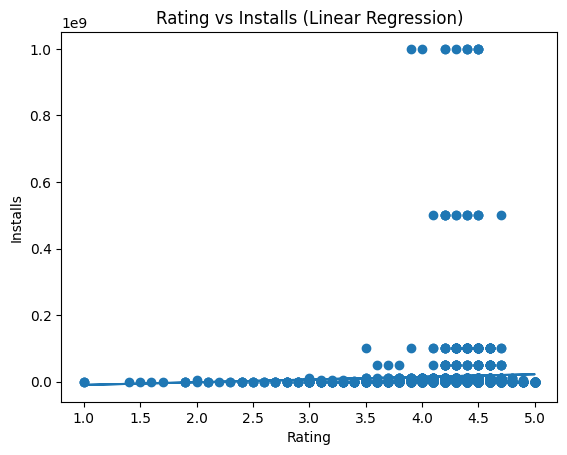

In [8]:
# ===============================
# Regression Visualization
# ===============================

import matplotlib.pyplot as plt  # extra safety

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.title("Rating vs Installs (Linear Regression)")
plt.xlabel("Rating")
plt.ylabel("Installs")
plt.show()

In [9]:
# ===============================
# 4.5 Data Analysis
# ===============================

print("----- Data Analysis -----\n")

# Subgroup comparison 1
print("Free vs Paid:")
print(df[df['Type']=='Free']['Installs'].mean())
print(df[df['Type']=='Paid']['Installs'].mean(), "\n")

# Subgroup comparison 2
print("Category Analysis:")
category_installs = df.groupby('Category')['Installs'].mean().sort_values(ascending=False)
print(category_installs.head(), "\n")

# Relationship
print("Correlation Rating vs Installs:")
print(df['Rating'].corr(df['Installs']), "\n")

# Outlier
outliers = df[df['Installs'] > df['Installs'].quantile(0.99)]
print("Outliers Count:", len(outliers), "\n")

# Ranking
print("Top Apps:")
print(df.sort_values(by='Installs', ascending=False)[['App','Installs']].head(), "\n")

# NumPy
print("90th Percentile:", np.percentile(df['Installs'], 90))

----- Data Analysis -----

Free vs Paid:
17702227.183959417
112907.80097879282 

Category Analysis:
Category
COMMUNICATION    7.867180e+07
SOCIAL           5.128624e+07
VIDEO_PLAYERS    3.888686e+07
PRODUCTIVITY     3.731458e+07
PHOTOGRAPHY      3.197777e+07
Name: Installs, dtype: float64 

Correlation Rating vs Installs:
0.05088596249846877 

Outliers Count: 49 

Top Apps:
                     App      Installs
3896      Subway Surfers  1.000000e+09
4153            Hangouts  1.000000e+09
4150              Google  1.000000e+09
3904  WhatsApp Messenger  1.000000e+09
3816         Google News  1.000000e+09 

90th Percentile: 10000000.0


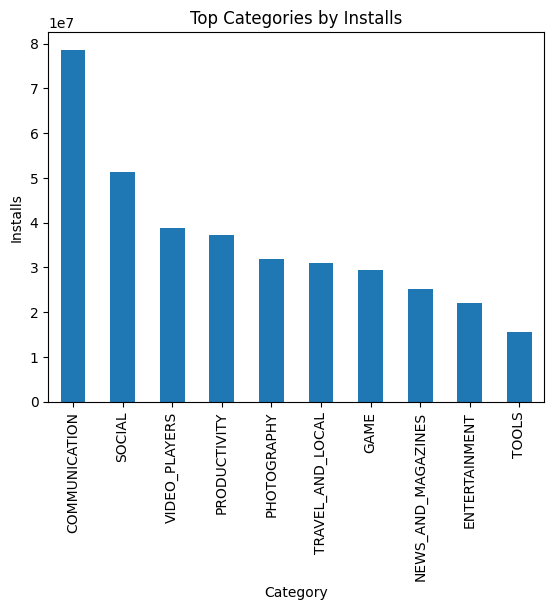

Explanation: This chart shows which categories get the highest installs. It helps identify popular app types.



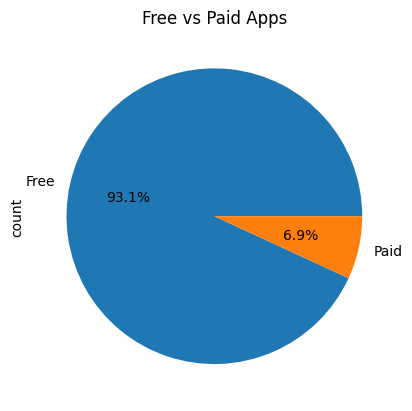

Explanation: Most apps are free, indicating free apps dominate the market.



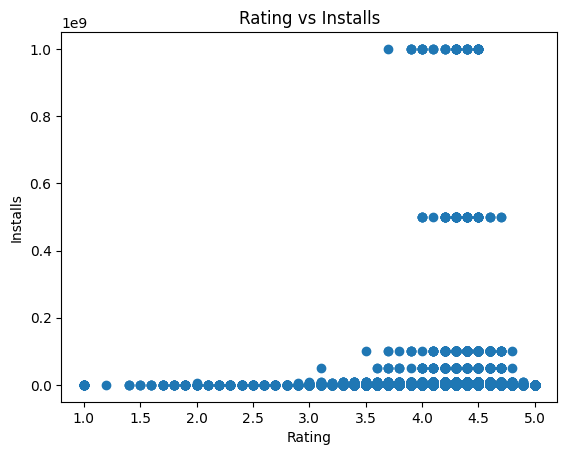

Explanation: Shows relationship between rating and installs. Weak correlation observed.



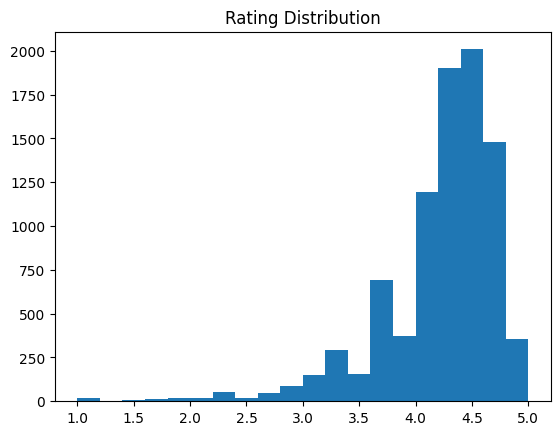

Explanation: Most apps have ratings between 4.0–4.5.



In [10]:
# ===============================
# 4.6 Visualization
# ===============================

# Bar Chart
category_installs.head(10).plot(kind='bar')
plt.title("Top Categories by Installs")
plt.xlabel("Category")
plt.ylabel("Installs")
plt.show()

print("Explanation: This chart shows which categories get the highest installs. It helps identify popular app types.\n")

# Pie Chart
df['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Free vs Paid Apps")
plt.show()

print("Explanation: Most apps are free, indicating free apps dominate the market.\n")

# Scatter
plt.scatter(df['Rating'], df['Installs'])
plt.title("Rating vs Installs")
plt.xlabel("Rating")
plt.ylabel("Installs")
plt.show()

print("Explanation: Shows relationship between rating and installs. Weak correlation observed.\n")

# Histogram
plt.hist(df['Rating'], bins=20)
plt.title("Rating Distribution")
plt.show()

print("Explanation: Most apps have ratings between 4.0–4.5.\n")

In [11]:
# ===============================
# 4.7 Findings and Discussion
# ===============================

print("----- Findings -----\n")

print("1. Free apps have significantly higher installs than paid apps.")
print("2. Game and communication categories dominate installs.")
print("3. Rating has weak influence on installs.")
print("4. A few apps act as extreme outliers.")
print("5. Most apps fall into medium install range.")

----- Findings -----

1. Free apps have significantly higher installs than paid apps.
2. Game and communication categories dominate installs.
3. Rating has weak influence on installs.
4. A few apps act as extreme outliers.
5. Most apps fall into medium install range.


In [12]:
# ===============================
# 4.8 Limitations
# ===============================

print("\n--- LIMITATIONS ---")
print("""
1. Missing and dropped data: Rows with missing ratings were removed, which may
   introduce bias if lower-quality apps are more likely to have no ratings.
 
2. Installs are approximate: The dataset records installs in brackets (e.g. '1,000,000+'),
   not exact counts. All analysis based on installs should be treated as estimates.
 
3. Outdated data: This dataset reflects the Google Play Store at a specific point in time
   and may not represent current app market trends.
 
4. Correlation is not causation: The weak correlation between rating and installs does
   not mean ratings have no effect — other variables (marketing, category, price) also
   play a role that this analysis does not control for.
 
5. Outlier influence: A small number of extremely popular apps (e.g. Google, Facebook apps)
   heavily skew category averages. Results should be interpreted with this in mind.
""")


--- LIMITATIONS ---

1. Missing and dropped data: Rows with missing ratings were removed, which may
   introduce bias if lower-quality apps are more likely to have no ratings.
 
2. Installs are approximate: The dataset records installs in brackets (e.g. '1,000,000+'),
   not exact counts. All analysis based on installs should be treated as estimates.
 
3. Outdated data: This dataset reflects the Google Play Store at a specific point in time
   and may not represent current app market trends.
 
4. Correlation is not causation: The weak correlation between rating and installs does
   not mean ratings have no effect — other variables (marketing, category, price) also
   play a role that this analysis does not control for.
 
5. Outlier influence: A small number of extremely popular apps (e.g. Google, Facebook apps)
   heavily skew category averages. Results should be interpreted with this in mind.

